# AR vs Spectrum Decay Across Models (Game24)

Same analysis/plots as the all-model precomputed notebook, using auto-discovered Game24 runs.


In [1]:
from pathlib import Path
import json
import math
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


def detect_project_root() -> Path:
    candidates = [
        Path.cwd().resolve(),
        Path('/home/mila/z/zihan.wang/scratch/Learning_from_Retrospection'),
        Path('/network/scratch/z/zihan.wang/Learning_from_Retrospection'),
    ]
    candidates.extend(Path.cwd().resolve().parents)
    seen = set()
    for c in candidates:
        k = str(c)
        if k in seen:
            continue
        seen.add(k)
        if (c / 'outputs').exists() and (c / 'research').exists():
            return c
    return Path.cwd().resolve()


PROJECT_ROOT = detect_project_root()
print('PROJECT_ROOT:', PROJECT_ROOT)

# Auto-discover Game24 merged metrics and keep best run per model tag.
search_glob = 'outputs/offline_game24*/**/merged/analysis_parallel/merged/metrics.jsonl'
metrics_files = sorted(PROJECT_ROOT.glob(search_glob))
if not metrics_files:
    raise FileNotFoundError(f'No Game24 metrics found under {PROJECT_ROOT / "outputs"}')

run_records = []
for m in metrics_files:
    # .../<output_root>/<model_limit>/merged/analysis_parallel/merged/metrics.jsonl
    try:
        model_limit_dir = m.parents[3].name
        output_root_dir = m.parents[4].name
        model_tag = model_limit_dir.rsplit('_limit', 1)[0] if '_limit' in model_limit_dir else model_limit_dir
        with m.open('r', encoding='utf-8') as f:
            n_rows = sum(1 for _ in f)
        run_records.append({
            'model_tag': model_tag,
            'output_root_dir': output_root_dir,
            'model_limit_dir': model_limit_dir,
            'metrics_path': m,
            'n_rows': n_rows,
        })
    except Exception:
        continue

if not run_records:
    raise RuntimeError('Found paths but failed to parse any Game24 run records.')

best_by_model = {}
for r in run_records:
    prev = best_by_model.get(r['model_tag'])
    if prev is None or (r['n_rows'], r['output_root_dir']) > (prev['n_rows'], prev['output_root_dir']):
        best_by_model[r['model_tag']] = r

# Stable colors (reused if >4 models)
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
MODEL_RUNS = []
for i, (model_tag, rec) in enumerate(sorted(best_by_model.items())):
    MODEL_RUNS.append({
        'name': model_tag,
        'metrics_dir': rec['metrics_path'].parent,
        'color': palette[i % len(palette)],
    })

print('Discovered Game24 models:', [m['name'] for m in MODEL_RUNS])
for m in MODEL_RUNS:
    print(' ', m['name'], '->', m['metrics_dir'])

EXCLUDE_MISSING_PATHS = True
EXCLUDE_TRUNCATED_RESPONSES = True
TRUNCATION_LENGTH_CUTOFF = 4096


def load_jsonl(path: Path):
    rows = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

model_runs = []
for cfg in MODEL_RUNS:
    metrics_path = cfg['metrics_dir'] / 'metrics.jsonl'
    if metrics_path.exists():
        model_runs.append(cfg)
    elif not EXCLUDE_MISSING_PATHS:
        raise FileNotFoundError(f'missing metrics: {metrics_path}')

print('Using models:', [m['name'] for m in model_runs])
all_samples = []
for cfg in model_runs:
    metrics_path = cfg['metrics_dir'] / 'metrics.jsonl'
    summary_path = cfg['metrics_dir'] / 'summary.json'
    rows = load_jsonl(metrics_path)
    for row in rows:
        row['model_name'] = cfg['name']
        row['model_color'] = cfg['color']
    print(cfg['name'], 'loaded samples:', len(rows))
    if summary_path.exists():
        print(cfg['name'], 'summary:', summary_path.read_text(encoding='utf-8')[:300], '...')
    all_samples.extend(rows)

samples_all = all_samples
if EXCLUDE_TRUNCATED_RESPONSES:
    before = len(samples_all)
    all_samples = [s for s in samples_all if int(s['response_length']) < TRUNCATION_LENGTH_CUTOFF]
    print(f'Filtered samples with response_length >= {TRUNCATION_LENGTH_CUTOFF}:', before - len(all_samples))
print('Combined samples:', len(all_samples))


def empirical_pass_rate(rows):
    by_question = defaultdict(list)
    for r in rows:
        by_question[r['question_uid']].append(r)
    if not by_question:
        return float('nan')
    passed = []
    for qid, group in by_question.items():
        passed.append(1.0 if any(x['success'] for x in group) else 0.0)
    return float(np.mean(passed))

model_pass_rates = []
for cfg in model_runs:
    rows = [s for s in all_samples if s['model_name'] == cfg['name']]
    pr = empirical_pass_rate(rows)
    cfg['pass_rate_empirical'] = pr
    model_pass_rates.append((cfg['name'], pr))

model_runs = sorted(
    model_runs,
    key=lambda cfg: (-(cfg.get('pass_rate_empirical', float('-inf')) if np.isfinite(cfg.get('pass_rate_empirical', float('nan'))) else float('-inf')), cfg['name'])
)

by_model = defaultdict(list)
for s in all_samples:
    by_model[s['model_name']].append(s)

print('Model order by empirical pass rate:')
for cfg in model_runs:
    print(' ', cfg['name'], cfg.get('pass_rate_empirical'))


PROJECT_ROOT: /home/mila/z/zihan.wang/scratch/Learning_from_Retrospection
Discovered Game24 models: ['qwen_qwen3_4b']
  qwen_qwen3_4b -> /home/mila/z/zihan.wang/scratch/Learning_from_Retrospection/outputs/offline_game24_l500_r4096_k32_sh100/qwen_qwen3_4b_limit500/merged/analysis_parallel/merged
Using models: ['qwen_qwen3_4b']
qwen_qwen3_4b loaded samples: 16000
qwen_qwen3_4b summary: {
  "input_dir": "/workspace/outputs/offline_game24_l500_r4096_k32_sh100/qwen_qwen3_4b_limit500/merged/analysis_parallel/shards",
  "output_dir": "/workspace/outputs/offline_game24_l500_r4096_k32_sh100/qwen_qwen3_4b_limit500/merged/analysis_parallel/merged",
  "num_metric_files": 100,
  "merged_rows ...
Filtered samples with response_length >= 4096: 2026
Combined samples: 13974
Model order by empirical pass rate:
  qwen_qwen3_4b 0.996


In [2]:
# Optional filter: keep only questions that have both success and failure trajectories.
MIXED_QUESTIONS_ONLY = False

from collections import defaultdict

if 'all_samples' in globals():
    samples_source = all_samples
    by_q = defaultdict(list)
    for s in samples_source:
        by_q[s['question_uid']].append(s)
    mixed_qids = {qid for qid, group in by_q.items() if any(x['success'] for x in group) and any((not x['success']) for x in group)}
    if MIXED_QUESTIONS_ONLY:
        before = len(samples_source)
        all_samples = [s for s in samples_source if s['question_uid'] in mixed_qids]
        if 'samples' in globals():
            samples = all_samples
        print('Mixed-question filter removed:', before - len(all_samples))
    print('Mixed questions:', len(mixed_qids))
    print('Samples after mixed-question filter:', len(all_samples))
else:
    samples_source = samples
    by_q = defaultdict(list)
    for s in samples_source:
        by_q[s['question_uid']].append(s)
    mixed_qids = {qid for qid, group in by_q.items() if any(x['success'] for x in group) and any((not x['success']) for x in group)}
    if MIXED_QUESTIONS_ONLY:
        before = len(samples_source)
        samples = [s for s in samples_source if s['question_uid'] in mixed_qids]
        print('Mixed-question filter removed:', before - len(samples))
    print('Mixed questions:', len(mixed_qids))
    print('Samples after mixed-question filter:', len(samples))


Mixed questions: 497
Samples after mixed-question filter: 13974


In [3]:
# Trend uncertainty band mode for binned mean plots.
TREND_ERROR_MODE = 'std'  # one of: 'stderr', 'std'
assert TREND_ERROR_MODE in {'stderr', 'std'}
print('TREND_ERROR_MODE =', TREND_ERROR_MODE)


TREND_ERROR_MODE = std


In [4]:
def empirical_pass_rate(rows):
    by_question = defaultdict(list)
    for r in rows:
        by_question[r['question_uid']].append(r)
    if not by_question:
        return float('nan')
    passed = []
    for qid, group in by_question.items():
        passed.append(1.0 if any(x['success'] for x in group) else 0.0)
    return float(np.mean(passed))


model_pass_rates = []
for cfg in model_runs:
    rows = [s for s in all_samples if s['model_name'] == cfg['name']]
    pr = empirical_pass_rate(rows)
    cfg['pass_rate_empirical'] = pr
    model_pass_rates.append((cfg['name'], pr))

model_runs = sorted(
    model_runs,
    key=lambda cfg: (-(cfg.get('pass_rate_empirical', float('-inf')) if np.isfinite(cfg.get('pass_rate_empirical', float('nan'))) else float('-inf')), cfg['name'])
)

by_model = defaultdict(list)
for s in all_samples:
    by_model[s['model_name']].append(s)

print('Model order by empirical pass rate:')
for cfg in model_runs:
    print(' ', cfg['name'], cfg.get('pass_rate_empirical'))

# Model-wise normalized metrics: z-score within each model.
normalized_metric_specs = [
    ('response_length', 'response_length_z_by_model'),
    ('analysis_length', 'analysis_length_z_by_model'),
    ('decay_rate', 'decay_rate_z_by_model'),
    ('ar_error', 'ar_error_z_by_model'),
]

for cfg in model_runs:
    rows = by_model[cfg['name']]
    for src_key, dst_key in normalized_metric_specs:
        arr = np.asarray([float(s[src_key]) for s in rows], dtype=np.float64)
        if arr.size == 0:
            continue
        mu = float(arr.mean())
        sigma = float(arr.std())
        if sigma <= 0:
            sigma = 1.0
        for s in rows:
            s[dst_key] = (float(s[src_key]) - mu) / sigma

all_samples = [s for cfg in model_runs for s in by_model[cfg['name']]]
print('Added model-wise z-scored metrics for models:', [cfg['name'] for cfg in model_runs])
for cfg in model_runs:
    print(cfg['name'])
    for _, dst_key in normalized_metric_specs:
        vals = np.asarray([float(s[dst_key]) for s in by_model[cfg['name']]], dtype=np.float64)
        if vals.size:
            print(' ', dst_key, {'mean': float(vals.mean()), 'std': float(vals.std()), 'median': float(np.median(vals))})


Model order by empirical pass rate:
  qwen_qwen3_4b 0.996
Added model-wise z-scored metrics for models: ['qwen_qwen3_4b']
qwen_qwen3_4b
  response_length_z_by_model {'mean': -6.30508796581168e-17, 'std': 0.9999999999999999, 'median': -0.23904431761473494}
  analysis_length_z_by_model {'mean': -6.30508796581168e-17, 'std': 0.9999999999999999, 'median': -0.23904431761473494}
  decay_rate_z_by_model {'mean': -6.610172867383213e-17, 'std': 1.0, 'median': -0.1471578473479363}
  ar_error_z_by_model {'mean': 2.288136761786497e-18, 'std': 1.0, 'median': -0.17109468108902384}


In [5]:
def summarize(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'n': int(arr.size),
        'mean': float(arr.mean()) if arr.size else None,
        'median': float(np.median(arr)) if arr.size else None,
        'std': float(arr.std()) if arr.size else None,
        'min': float(arr.min()) if arr.size else None,
        'max': float(arr.max()) if arr.size else None,
    }

for model_name, rows in by_model.items():
    success_ar = [s['ar_error'] for s in rows if s['success']]
    failure_ar = [s['ar_error'] for s in rows if not s['success']]
    success_decay = [s['decay_rate'] for s in rows if s['success']]
    failure_decay = [s['decay_rate'] for s in rows if not s['success']]
    print(model_name)
    print('  total:', len(rows))
    print('  success rate:', float(np.mean([1.0 if s['success'] else 0.0 for s in rows])) if rows else None)
    print('  Success AR error stats:', summarize(success_ar))
    print('  Failure AR error stats:', summarize(failure_ar))
    print('  Success decay stats:', summarize(success_decay))
    print('  Failure decay stats:', summarize(failure_decay))
    print()


qwen_qwen3_4b
  total: 13974
  success rate: 0.6630170316301703
  Success AR error stats: {'n': 9265, 'mean': 1.7684414184485908, 'median': 1.740718960762024, 'std': 0.37808368325476477, 'min': 0.9474833607673645, 'max': 5.584582328796387}
  Failure AR error stats: {'n': 4709, 'mean': 1.7979312867565402, 'median': 1.6028287410736084, 'std': 0.7568810687126556, 'min': 0.953118085861206, 'max': 6.751041412353516}
  Success decay stats: {'n': 9265, 'mean': 1.182252445565546, 'median': 1.1418028095214676, 'std': 0.6862334320636672, 'min': 0.9585876170188151, 'max': 15.715530990651013}
  Failure decay stats: {'n': 4709, 'mean': 1.8776625825194322, 'median': 1.2164905052692556, 'std': 2.7434102164286682, 'min': 0.9857579900803327, 'max': 15.721583621056496}



Pooled Pearson correlation(decay_rate, ar_error): 0.6476564435872433


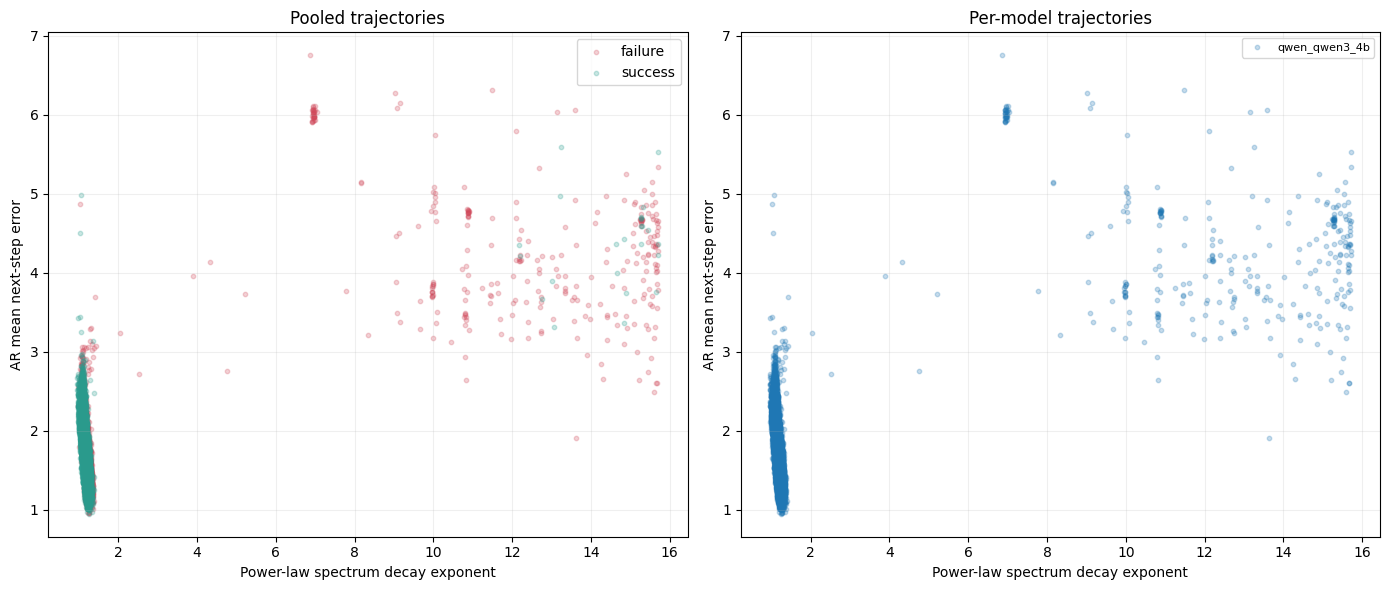

In [6]:
# Pooled and per-model AR-vs-decay scatter.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.asarray([s['decay_rate'] for s in all_samples], dtype=np.float64)
y = np.asarray([s['ar_error'] for s in all_samples], dtype=np.float64)
labels = np.asarray([1 if s['success'] else 0 for s in all_samples], dtype=np.int64)
valid = x < np.percentile(x, 99.99)
x = x[valid]
y = y[valid]
labels = labels[valid]

corr = np.corrcoef(x, y)[0, 1]
print('Pooled Pearson correlation(decay_rate, ar_error):', float(corr))
failure = labels == 0
success = labels == 1
if failure.any():
    axes[0].scatter(x[failure], y[failure], s=10, alpha=0.25, c='#d1495b', label='failure')
if success.any():
    axes[0].scatter(x[success], y[success], s=10, alpha=0.25, c='#2a9d8f', label='success')
axes[0].set_title('Pooled trajectories')
axes[0].set_xlabel('Power-law spectrum decay exponent')
axes[0].set_ylabel('AR mean next-step error')
axes[0].grid(alpha=0.2)
axes[0].legend()

for cfg in model_runs:
    rows = by_model[cfg['name']]
    xv = np.asarray([s['decay_rate'] for s in rows], dtype=np.float64)
    yv = np.asarray([s['ar_error'] for s in rows], dtype=np.float64)
    if xv.size == 0:
        continue
    keep = xv < np.percentile(xv, 99.99)
    axes[1].scatter(xv[keep], yv[keep], s=10, alpha=0.25, c=cfg['color'], label=cfg['name'])
axes[1].set_title('Per-model trajectories')
axes[1].set_xlabel('Power-law spectrum decay exponent')
axes[1].set_ylabel('AR mean next-step error')
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


In [7]:
# Per-model within-question paired gap summaries.
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law spectrum decay exponent'),
    ('ar_error', 'AR mean next-step error'),
    ('response_length_z_by_model', 'Response length z-score within model'),
    ('analysis_length_z_by_model', 'Analysis length z-score within model'),
    ('decay_rate_z_by_model', 'Decay rate z-score within model'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
]

def paired_gaps(rows, key):
    by_question = defaultdict(list)
    for r in rows:
        by_question[r['question_uid']].append(r)
    vals = []
    for qid, group in by_question.items():
        succ = [x for x in group if x['success']]
        fail = [x for x in group if not x['success']]
        if not succ or not fail:
            continue
        vals.append(float(np.mean([x[key] for x in fail]) - np.mean([x[key] for x in succ])))
    return np.asarray(vals, dtype=np.float64)

for model_name, rows in by_model.items():
    print(model_name)
    for key, label in metric_specs:
        vals = paired_gaps(rows, key)
        print(label)
        print('  mixed-outcome questions:', int(vals.size))
        print('  positive:', int(np.sum(vals > 0)))
        print('  negative:', int(np.sum(vals < 0)))
        print('  zero:', int(np.sum(vals == 0)))
        print('  mean gap:', float(vals.mean()) if vals.size else None)
        print('  median gap:', float(np.median(vals)) if vals.size else None)
    print()


qwen_qwen3_4b
Response length
  mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -118.76765636148245
  median gap: -106.39583333333326
Analysis length
  mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -118.76765636148245
  median gap: -106.39583333333326
Power-law spectrum decay exponent
  mixed-outcome questions: 497
  positive: 410
  negative: 87
  zero: 0
  mean gap: 0.8312105478886881
  median gap: 0.09470755481437343
AR mean next-step error
  mixed-outcome questions: 497
  positive: 316
  negative: 181
  zero: 0
  mean gap: 0.15805989305091267
  median gap: 0.08506063052586144
Response length z-score within model
  mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -0.12934877919476917
  median gap: -0.11587473875202278
Analysis length z-score within model
  mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -0.12934877919476917
  median gap: -0.1158

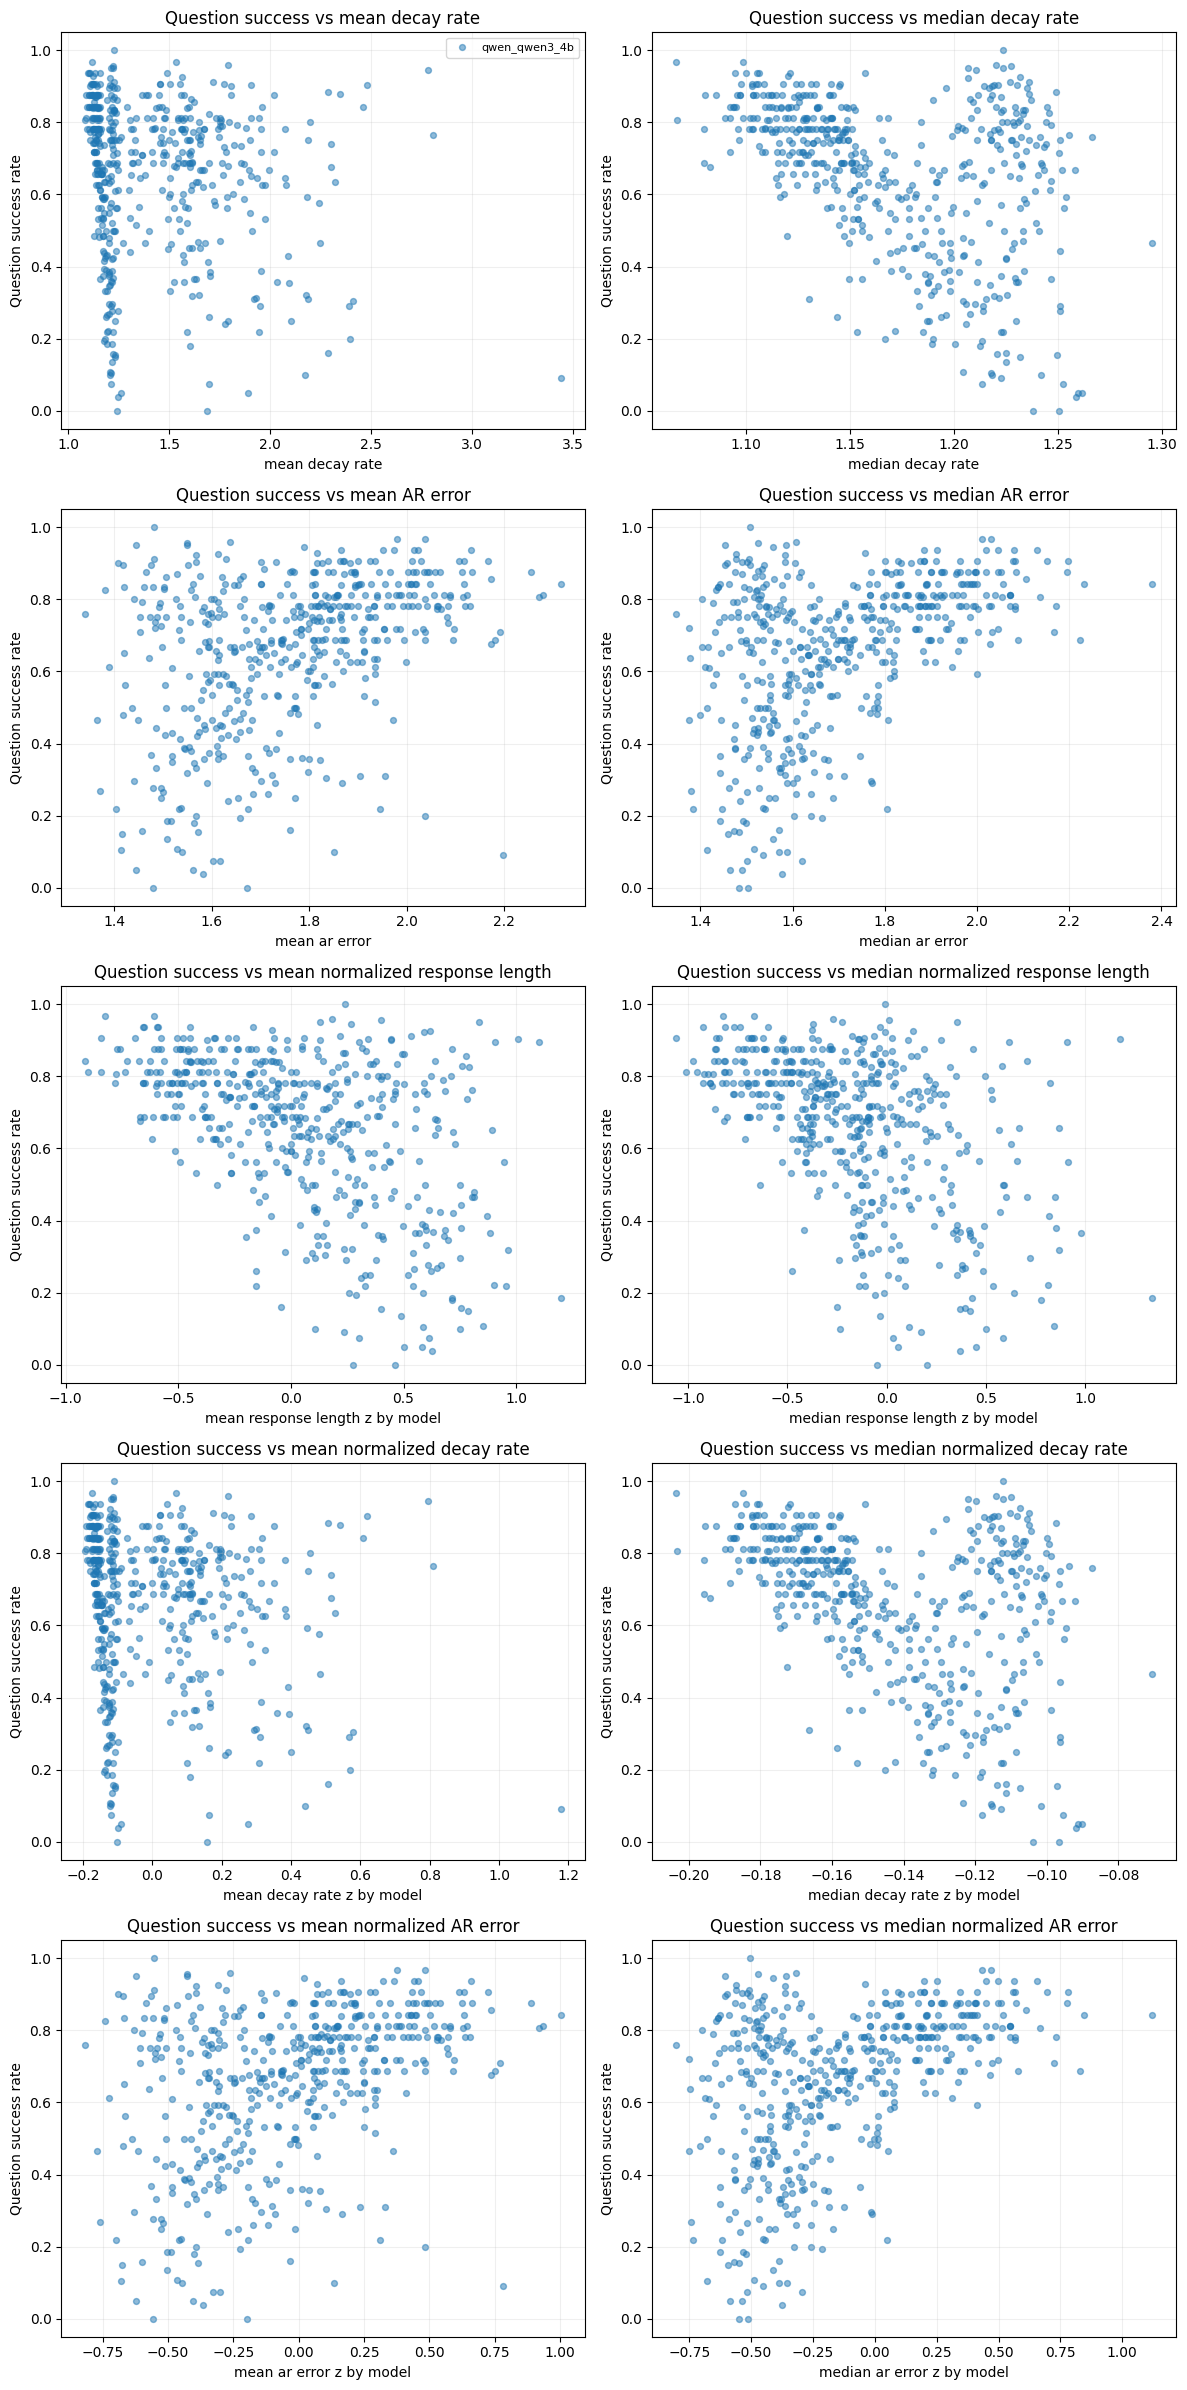

In [8]:
# Compare models on question-level success vs mean metrics.
question_rows = []
for model_name, rows in by_model.items():
    by_question = defaultdict(list)
    for r in rows:
        by_question[r['question_uid']].append(r)
    for qid, group in by_question.items():
        succ = np.asarray([1.0 if x['success'] else 0.0 for x in group], dtype=np.float64)
        dec = np.asarray([x['decay_rate'] for x in group], dtype=np.float64)
        ar = np.asarray([x['ar_error'] for x in group], dtype=np.float64)
        respz = np.asarray([x['response_length_z_by_model'] for x in group], dtype=np.float64)
        analz = np.asarray([x['analysis_length_z_by_model'] for x in group], dtype=np.float64)
        decz = np.asarray([x['decay_rate_z_by_model'] for x in group], dtype=np.float64)
        arz = np.asarray([x['ar_error_z_by_model'] for x in group], dtype=np.float64)
        question_rows.append({
            'model_name': model_name,
            'question_uid': qid,
            'success_rate': float(succ.mean()),
            'mean_decay_rate': float(dec.mean()),
            'median_decay_rate': float(np.median(dec)),
            'mean_ar_error': float(ar.mean()),
            'median_ar_error': float(np.median(ar)),
            'mean_response_length_z_by_model': float(respz.mean()),
            'median_response_length_z_by_model': float(np.median(respz)),
            'mean_analysis_length_z_by_model': float(analz.mean()),
            'median_analysis_length_z_by_model': float(np.median(analz)),
            'mean_decay_rate_z_by_model': float(decz.mean()),
            'median_decay_rate_z_by_model': float(np.median(decz)),
            'mean_ar_error_z_by_model': float(arz.mean()),
            'median_ar_error_z_by_model': float(np.median(arz)),
        })

fig, axes = plt.subplots(5, 2, figsize=(12, 24))
plot_specs = [
    ('mean_decay_rate', 'Question success vs mean decay rate'),
    ('median_decay_rate', 'Question success vs median decay rate'),
    ('mean_ar_error', 'Question success vs mean AR error'),
    ('median_ar_error', 'Question success vs median AR error'),
    ('mean_response_length_z_by_model', 'Question success vs mean normalized response length'),
    ('median_response_length_z_by_model', 'Question success vs median normalized response length'),
    ('mean_decay_rate_z_by_model', 'Question success vs mean normalized decay rate'),
    ('median_decay_rate_z_by_model', 'Question success vs median normalized decay rate'),
    ('mean_ar_error_z_by_model', 'Question success vs mean normalized AR error'),
    ('median_ar_error_z_by_model', 'Question success vs median normalized AR error'),
]
for ax, (key, title) in zip(axes.flat, plot_specs):
    for cfg in model_runs:
        rows = [r for r in question_rows if r['model_name'] == cfg['name']]
        if not rows:
            continue
        ax.scatter(
            [r[key] for r in rows],
            [r['success_rate'] for r in rows],
            s=18,
            alpha=0.5,
            c=cfg['color'],
            label=cfg['name'],
        )
    ax.set_title(title)
    ax.set_xlabel(key.replace('_', ' '))
    ax.set_ylabel('Question success rate')
    ax.grid(alpha=0.2)
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


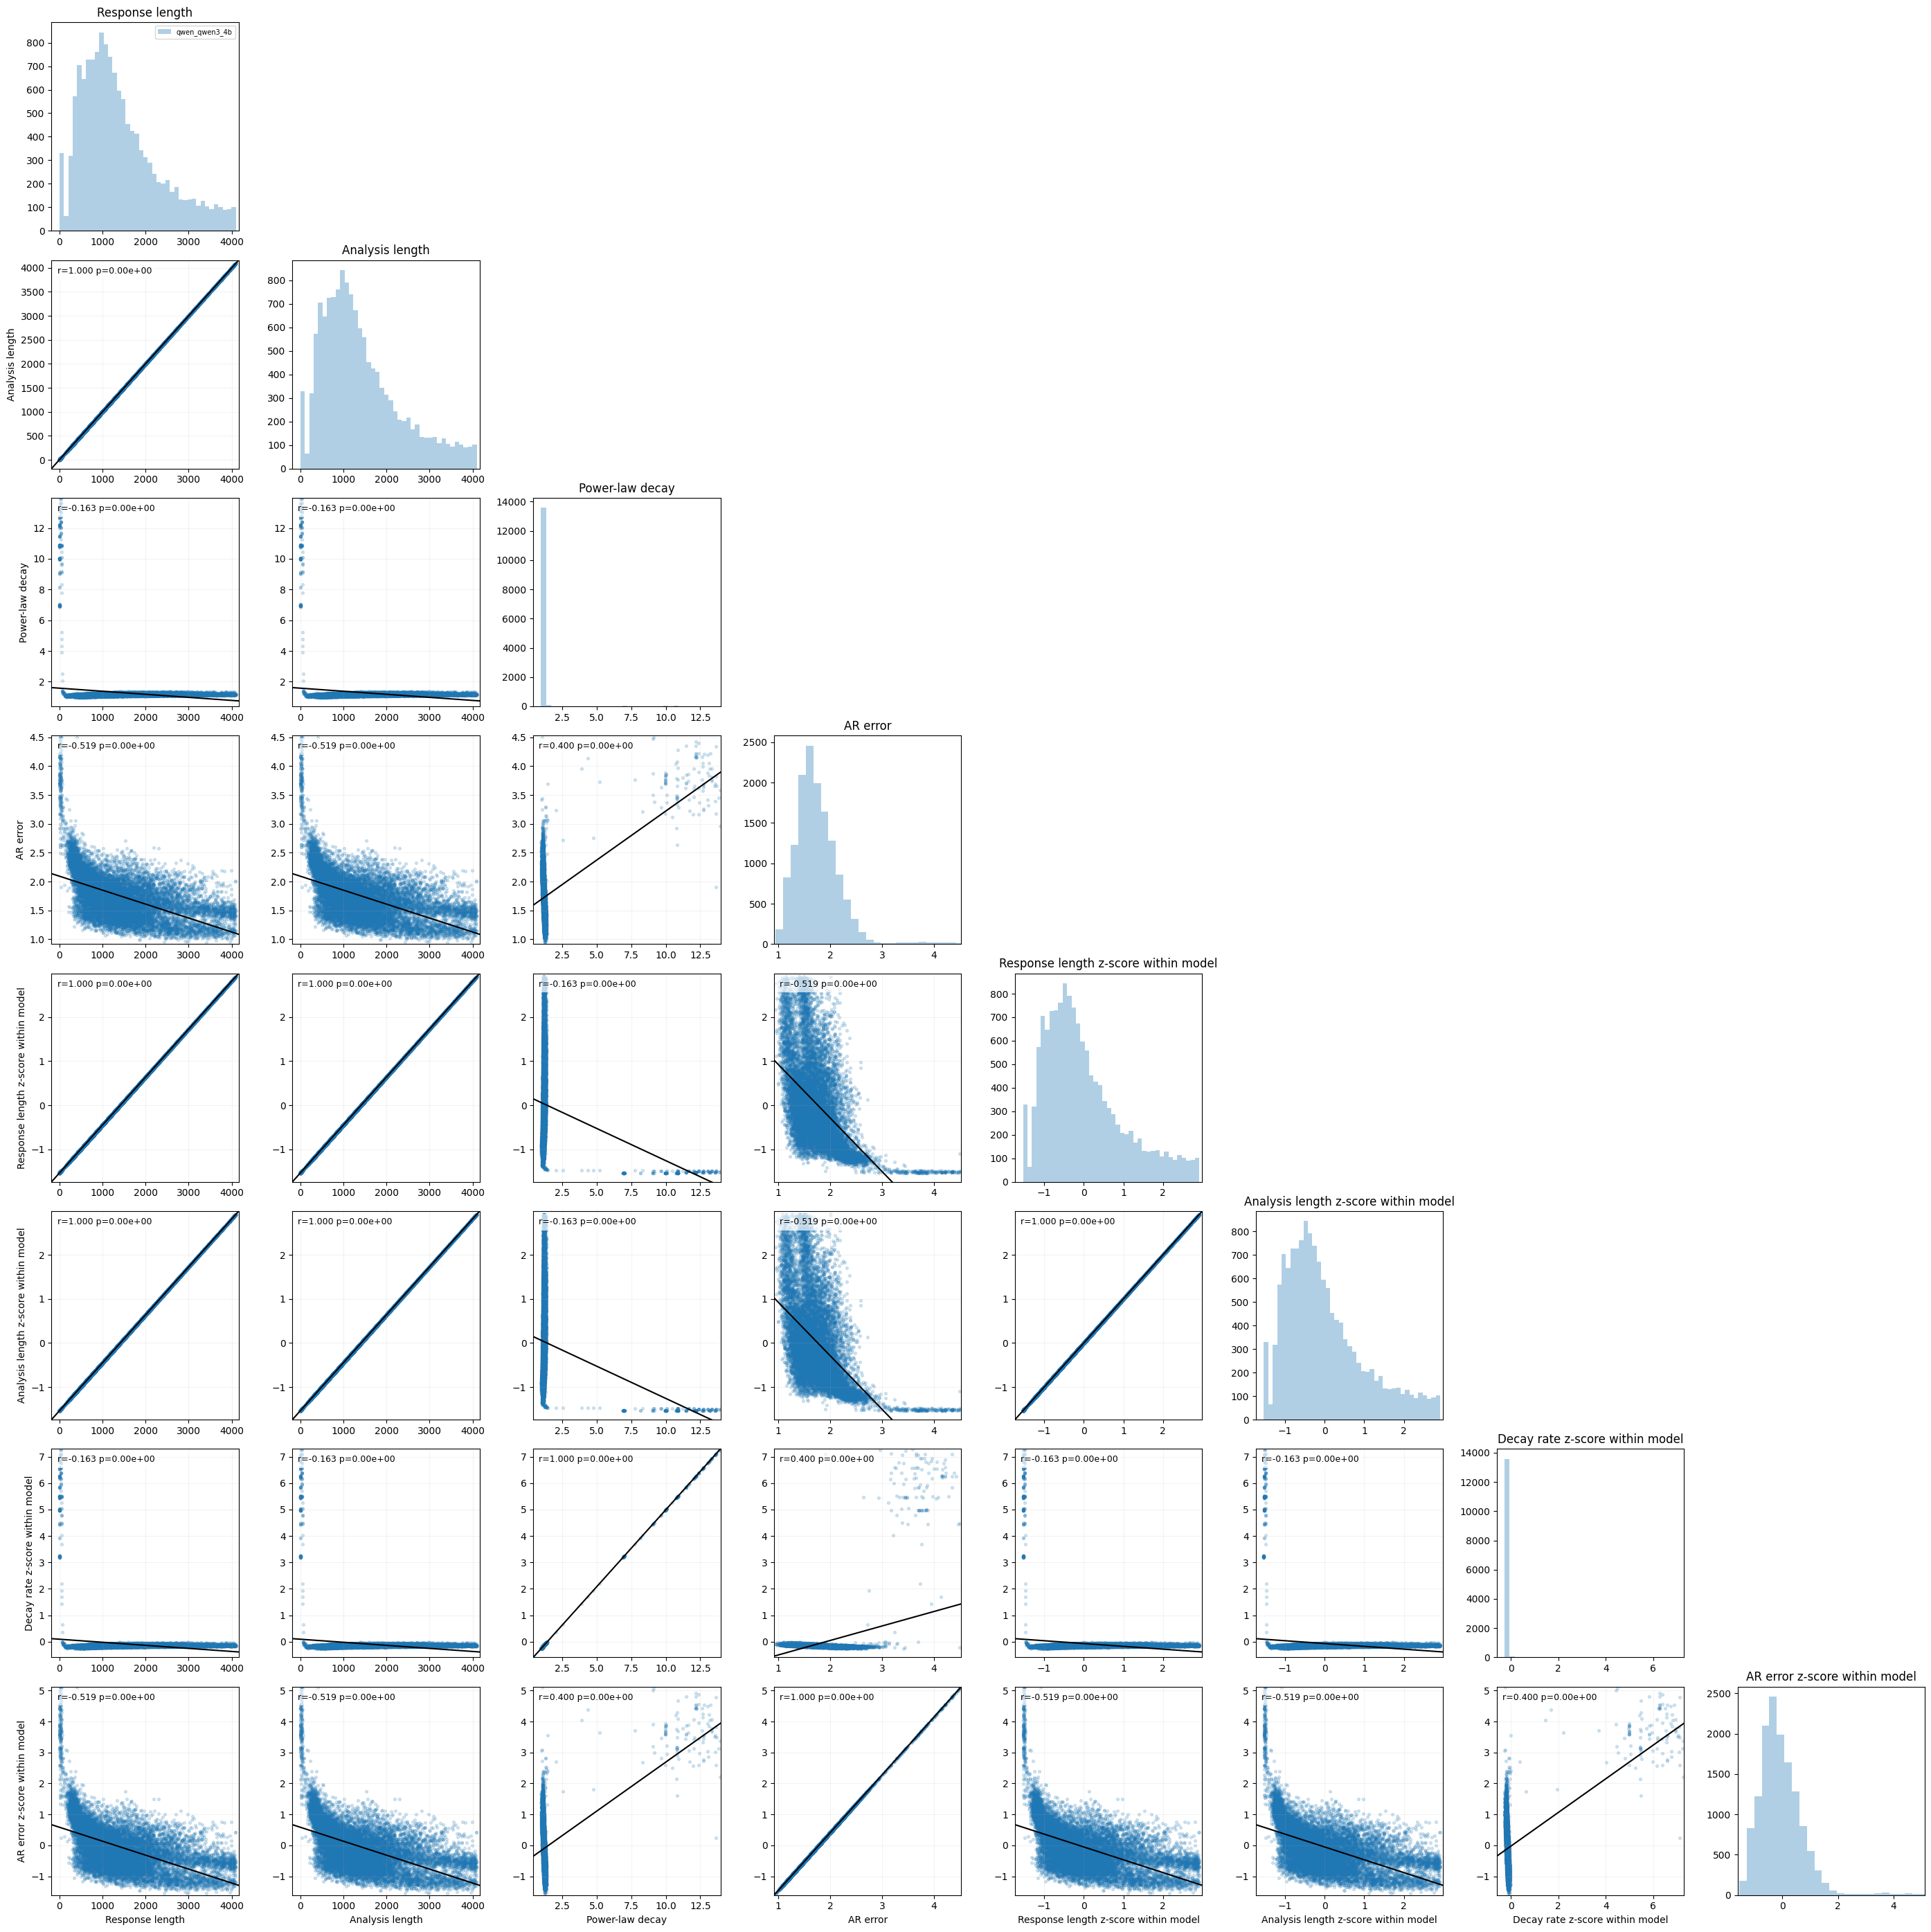

In [9]:
# Lower-triangle regression matrix on all pooled samples, colored by model.
def rankdata_average(a):
    a = np.asarray(a, dtype=np.float64)
    order = np.argsort(a, kind='mergesort')
    ranks = np.empty(len(a), dtype=np.float64)
    i = 0
    while i < len(a):
        j = i + 1
        while j < len(a) and a[order[j]] == a[order[i]]:
            j += 1
        avg_rank = 0.5 * (i + j - 1) + 1.0
        ranks[order[i:j]] = avg_rank
        i = j
    return ranks

def normal_cdf(z):
    return 0.5 * (1.0 + math.erf(z / math.sqrt(2.0)))

def pearson_p_value(r, n):
    if n < 4 or not np.isfinite(r) or abs(r) >= 1.0:
        return 0.0 if abs(r) >= 1.0 else float('nan')
    z = np.arctanh(np.clip(r, -0.999999, 0.999999)) * math.sqrt(max(n - 3, 1))
    return float(2.0 * (1.0 - normal_cdf(abs(z))))

metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
    ('response_length_z_by_model', 'Response length z-score within model'),
    ('analysis_length_z_by_model', 'Analysis length z-score within model'),
    ('decay_rate_z_by_model', 'Decay rate z-score within model'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
]
metric_arrays = {key: np.asarray([float(s[key]) for s in all_samples], dtype=np.float64) for key, _ in metric_specs}
model_names = [s['model_name'] for s in all_samples]
color_map = {cfg['name']: cfg['color'] for cfg in model_runs}

limits = {}
for key, _ in metric_specs:
    arr = metric_arrays[key]
    lo, hi = np.percentile(arr, [1.0, 99.0])
    pad = 0.05 * max(hi - lo, 1e-8)
    limits[key] = (float(lo - pad), float(hi + pad))

n = len(metric_specs)
fig, axes = plt.subplots(n, n, figsize=(3.5 * n, 3.5 * n))
for i, (key_i, label_i) in enumerate(metric_specs):
    for j, (key_j, label_j) in enumerate(metric_specs):
        ax = axes[i, j]
        if i < j:
            ax.axis('off')
            continue
        if i == j:
            for cfg in model_runs:
                vals = np.asarray([float(s[key_i]) for s in all_samples if s['model_name'] == cfg['name']], dtype=np.float64)
                if vals.size:
                    ax.hist(vals, bins=40, alpha=0.35, color=cfg['color'], label=cfg['name'])
            ax.set_xlim(*limits[key_i])
            ax.set_title(label_i)
            if i == 0 and j == 0:
                ax.legend(fontsize=7)
            continue
        x = metric_arrays[key_j]
        y = metric_arrays[key_i]
        keep = (
            (x >= limits[key_j][0]) & (x <= limits[key_j][1]) &
            (y >= limits[key_i][0]) & (y <= limits[key_i][1])
        )
        xk = x[keep]
        yk = y[keep]
        mk = np.asarray(model_names)[keep]
        for cfg in model_runs:
            mask = mk == cfg['name']
            if np.any(mask):
                ax.scatter(xk[mask], yk[mask], s=8, alpha=0.18, c=cfg['color'])
        if xk.size >= 2:
            coef = np.polyfit(xk, yk, deg=1)
            xs = np.linspace(*limits[key_j], 200)
            ys = coef[0] * xs + coef[1]
            ax.plot(xs, ys, c='black', lw=1.5)
            r = float(np.corrcoef(xk, yk)[0, 1])
            p = pearson_p_value(r, int(xk.size))
            ax.text(0.03, 0.97, f'r={r:.3f} p={p:.2e}', transform=ax.transAxes, va='top', ha='left', fontsize=9,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        ax.set_xlim(*limits[key_j])
        ax.set_ylim(*limits[key_i])
        if i == n - 1:
            ax.set_xlabel(label_j)
        if j == 0:
            ax.set_ylabel(label_i)
        ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


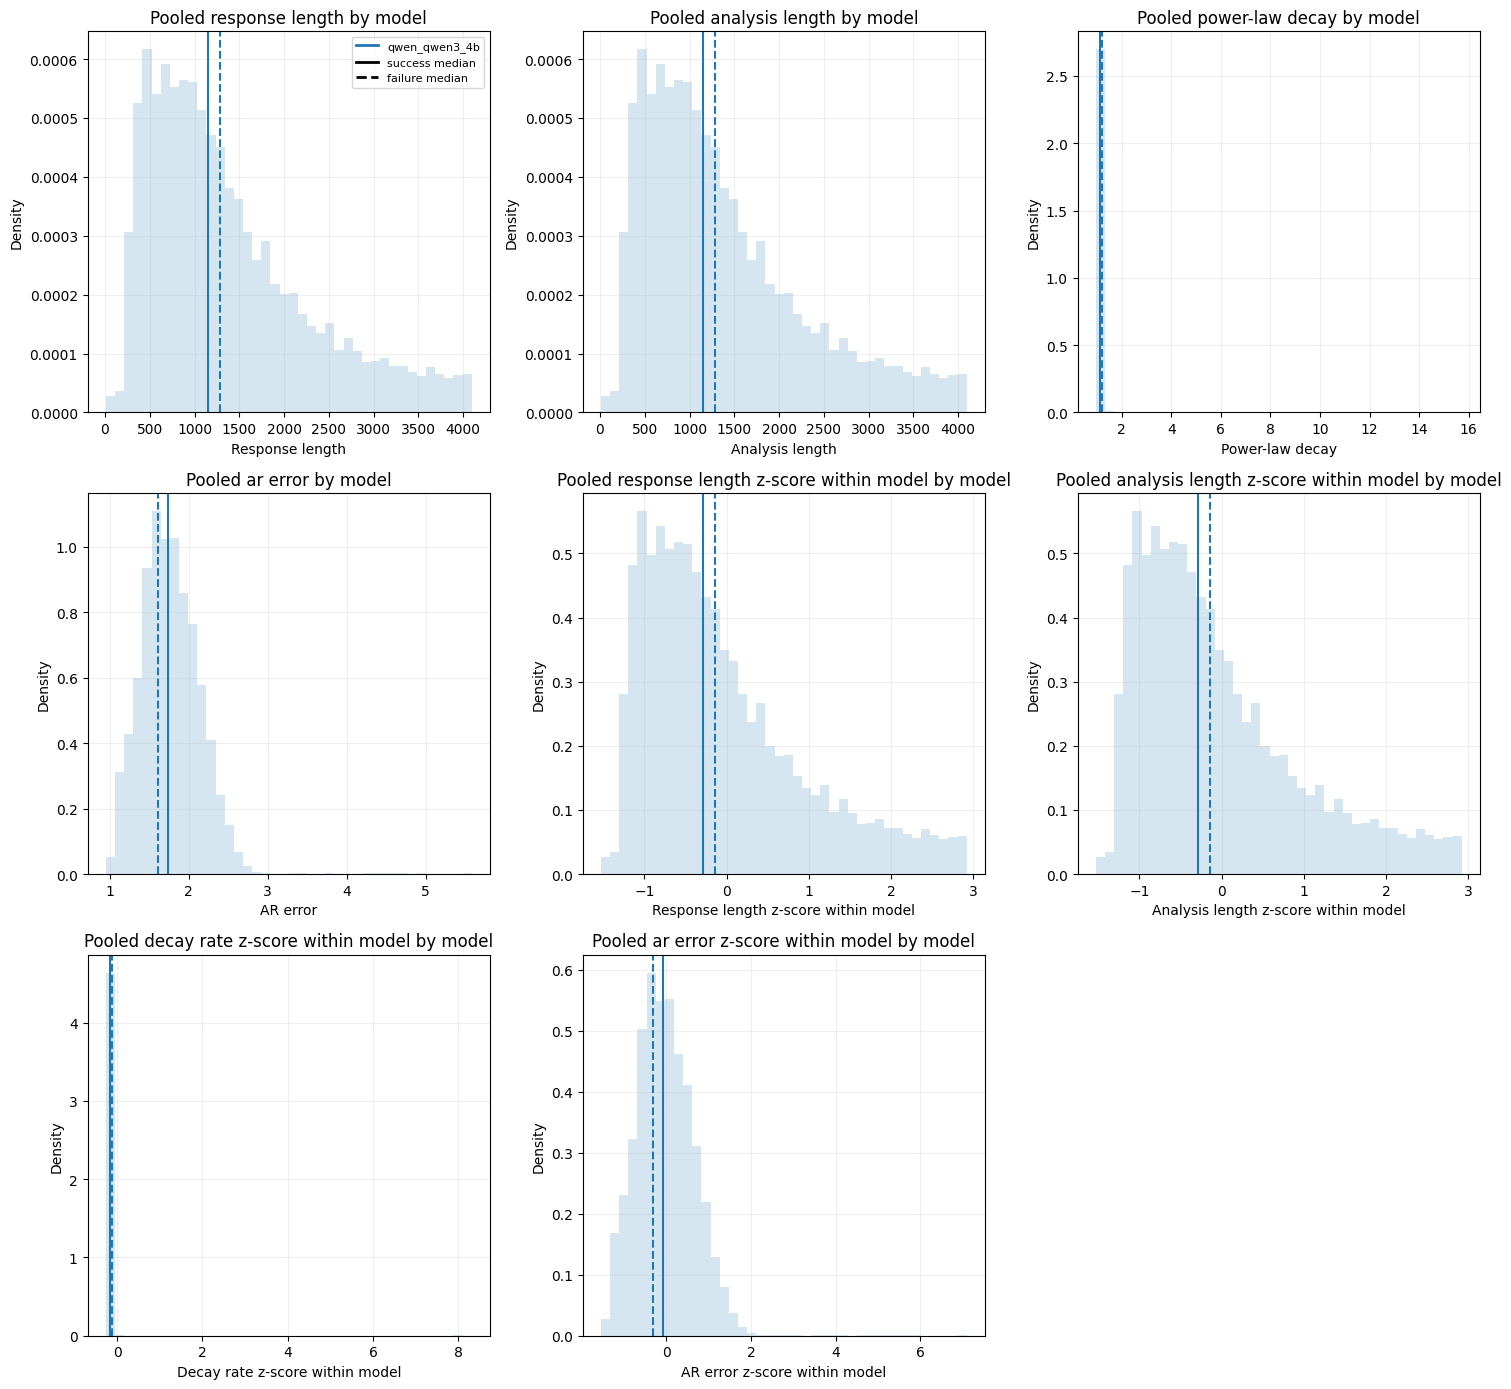

In [10]:
# Pooled success-vs-failure metric distributions, colored by model.
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
    ('response_length_z_by_model', 'Response length z-score within model'),
    ('analysis_length_z_by_model', 'Analysis length z-score within model'),
    ('decay_rate_z_by_model', 'Decay rate z-score within model'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
for ax, (key, label) in zip(axes.flat, metric_specs):
    for cfg in model_runs:
        rows = by_model[cfg['name']]
        succ = np.asarray([float(s[key]) for s in rows if s['success']], dtype=np.float64)
        fail = np.asarray([float(s[key]) for s in rows if not s['success']], dtype=np.float64)
        if succ.size:
            ax.hist(succ, bins=40, alpha=0.18, color=cfg['color'], density=True)
            ax.axvline(float(np.median(succ)), color=cfg['color'], lw=1.5, linestyle='-')
        if fail.size:
            ax.axvline(float(np.median(fail)), color=cfg['color'], lw=1.5, linestyle='--')
    ax.set_title(f'Pooled {label.lower()} by model')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.grid(alpha=0.2)
handles = [plt.Line2D([0], [0], color=cfg['color'], lw=2, label=cfg['name']) for cfg in model_runs]
handles += [
    plt.Line2D([0], [0], color='black', lw=2, linestyle='-', label='success median'),
    plt.Line2D([0], [0], color='black', lw=2, linestyle='--', label='failure median'),
]
for ax in axes.flat[len(metric_specs):]:
    ax.axis('off')
axes[0, 0].legend(handles=handles, fontsize=8)
plt.tight_layout()
plt.show()


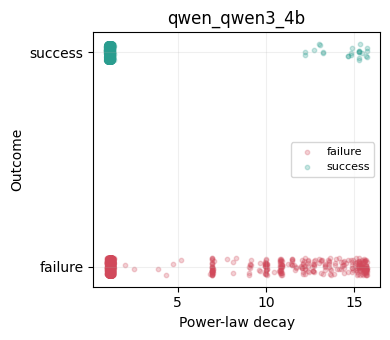

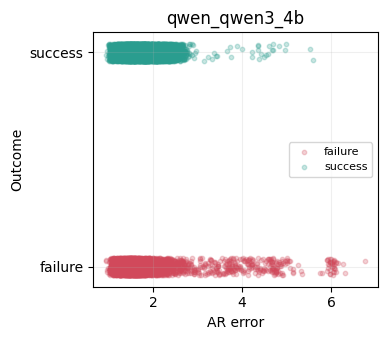

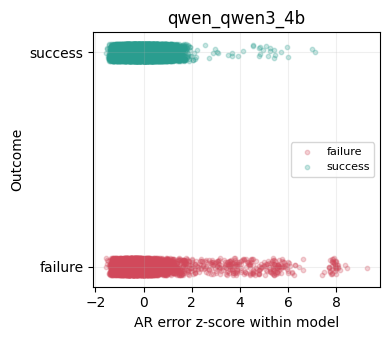

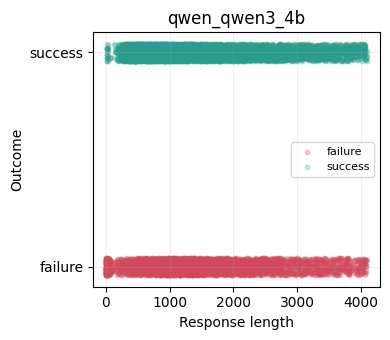

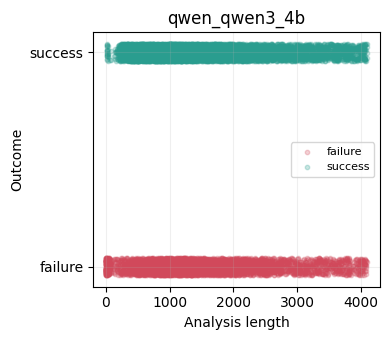

In [11]:
# Faceted success/failure scatter by model.
metric_specs = [
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
]

for key, label in metric_specs:
    n_models = len(model_runs)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 3.5), squeeze=False)
    for ax, cfg in zip(axes[0], model_runs):
        rows = by_model[cfg['name']]
        x = np.asarray([float(s[key]) for s in rows], dtype=np.float64)
        y = np.asarray([1.0 if s['success'] else 0.0 for s in rows], dtype=np.float64)
        if x.size == 0:
            ax.set_title(cfg['name'])
            ax.axis('off')
            continue
        jitter = (np.random.rand(len(y)) - 0.5) * 0.08
        fail = y == 0
        succ = y == 1
        if fail.any():
            ax.scatter(x[fail], y[fail] + jitter[fail], s=10, alpha=0.25, c='#d1495b', label='failure')
        if succ.any():
            ax.scatter(x[succ], y[succ] + jitter[succ], s=10, alpha=0.25, c='#2a9d8f', label='success')
        ax.set_title(cfg['name'])
        ax.set_xlabel(label)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['failure', 'success'])
        ax.grid(alpha=0.2)
    axes[0][0].set_ylabel('Outcome')
    axes[0][0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


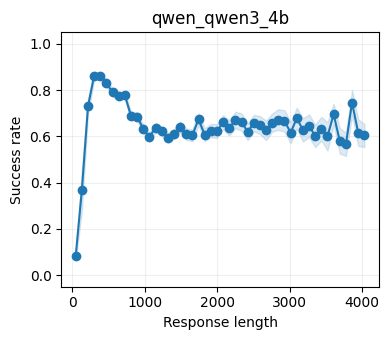

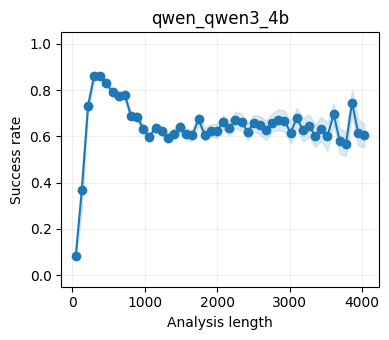

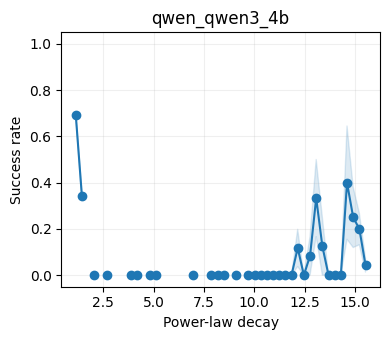

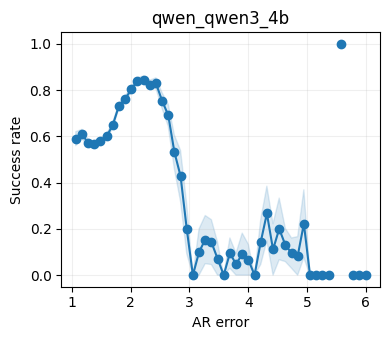

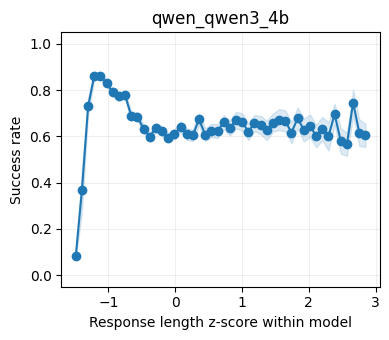

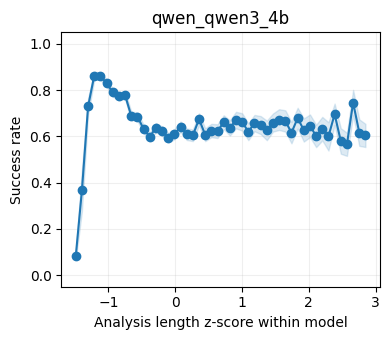

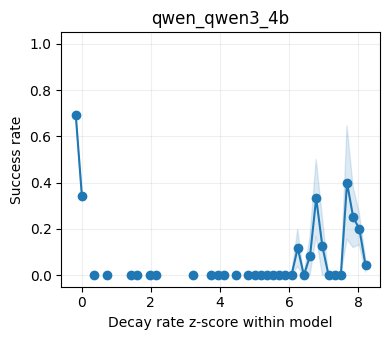

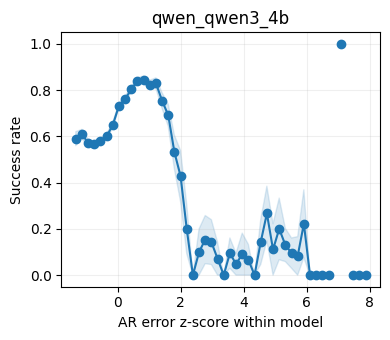

In [12]:
# Faceted binned success-rate curves by model.
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law decay'),
    ('ar_error', 'AR error'),
    ('response_length_z_by_model', 'Response length z-score within model'),
    ('analysis_length_z_by_model', 'Analysis length z-score within model'),
    ('decay_rate_z_by_model', 'Decay rate z-score within model'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
]

for key, label in metric_specs:
    n_models = len(model_runs)
    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 3.5), squeeze=False)
    for ax, cfg in zip(axes[0], model_runs):
        rows = by_model[cfg['name']]
        x = np.asarray([float(s[key]) for s in rows], dtype=np.float64)
        y = np.asarray([1.0 if s['success'] else 0.0 for s in rows], dtype=np.float64)
        if x.size < 8:
            ax.set_title(cfg['name'])
            ax.axis('off')
            continue
        lo, hi = np.percentile(x, [.1, 99.9])
        bins = np.linspace(lo, hi, 49)
        centers = 0.5 * (bins[:-1] + bins[1:])
        rates = []
        counts = []
        errs = []
        for b0, b1 in zip(bins[:-1], bins[1:]):
            mask = (x >= b0) & (x < b1)
            vals = y[mask]
            counts.append(int(mask.sum()))
            rates.append(float(vals.mean()) if mask.any() else np.nan)
            std = float(vals.std(ddof=1)) if vals.size > 1 else 0.0
            errs.append(std / math.sqrt(vals.size) if vals.size else np.nan)
        ax.plot(centers, rates, marker='o', color=cfg['color'])
        ax.fill_between(centers, np.asarray(rates) - np.asarray(errs), np.asarray(rates) + np.asarray(errs), color=cfg['color'], alpha=0.15)
        ax.set_title(cfg['name'])
        ax.set_xlabel(label)
        ax.set_ylabel('Success rate')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


In [13]:
# Marginalized across all models: treat all responses as one pooled dataset.
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law spectrum decay exponent'),
    ('ar_error', 'AR mean next-step error'),
    ('response_length_z_by_model', 'Response length z-score within model'),
    ('analysis_length_z_by_model', 'Analysis length z-score within model'),
    ('decay_rate_z_by_model', 'Decay rate z-score within model'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
]

print('Marginalized pooled sample count:', len(all_samples))
print('Marginalized pooled model counts:')
for cfg in model_runs:
    print(' ', cfg['name'], len(by_model[cfg['name']]))
print()

for key, label in metric_specs:
    succ = np.asarray([float(s[key]) for s in all_samples if s['success']], dtype=np.float64)
    fail = np.asarray([float(s[key]) for s in all_samples if not s['success']], dtype=np.float64)
    print(label)
    print('  success stats:', summarize(succ))
    print('  failure stats:', summarize(fail))
    print('  mean(success) - mean(failure):', float(succ.mean() - fail.mean()) if succ.size and fail.size else None)
    print('  median(success) - median(failure):', float(np.median(succ) - np.median(fail)) if succ.size and fail.size else None)
    print()


Marginalized pooled sample count: 13974
Marginalized pooled model counts:
  qwen_qwen3_4b 13974

Response length
  success stats: {'n': 9265, 'mean': 1383.9654614139233, 'median': 1148.0, 'std': 906.4865222963778, 'min': 10.0, 'max': 4094.0}
  failure stats: {'n': 4709, 'mean': 1474.5466128689743, 'median': 1290.0, 'std': 937.9163521729922, 'min': 4.0, 'max': 4095.0}
  mean(success) - mean(failure): -90.58115145505099
  median(success) - median(failure): -142.0

Analysis length
  success stats: {'n': 9265, 'mean': 1383.9654614139233, 'median': 1148.0, 'std': 906.4865222963778, 'min': 10.0, 'max': 4094.0}
  failure stats: {'n': 4709, 'mean': 1474.5466128689743, 'median': 1290.0, 'std': 937.9163521729922, 'min': 4.0, 'max': 4095.0}
  mean(success) - mean(failure): -90.58115145505099
  median(success) - median(failure): -142.0

Power-law spectrum decay exponent
  success stats: {'n': 9265, 'mean': 1.182252445565546, 'median': 1.1418028095214676, 'std': 0.6862334320636672, 'min': 0.9585876

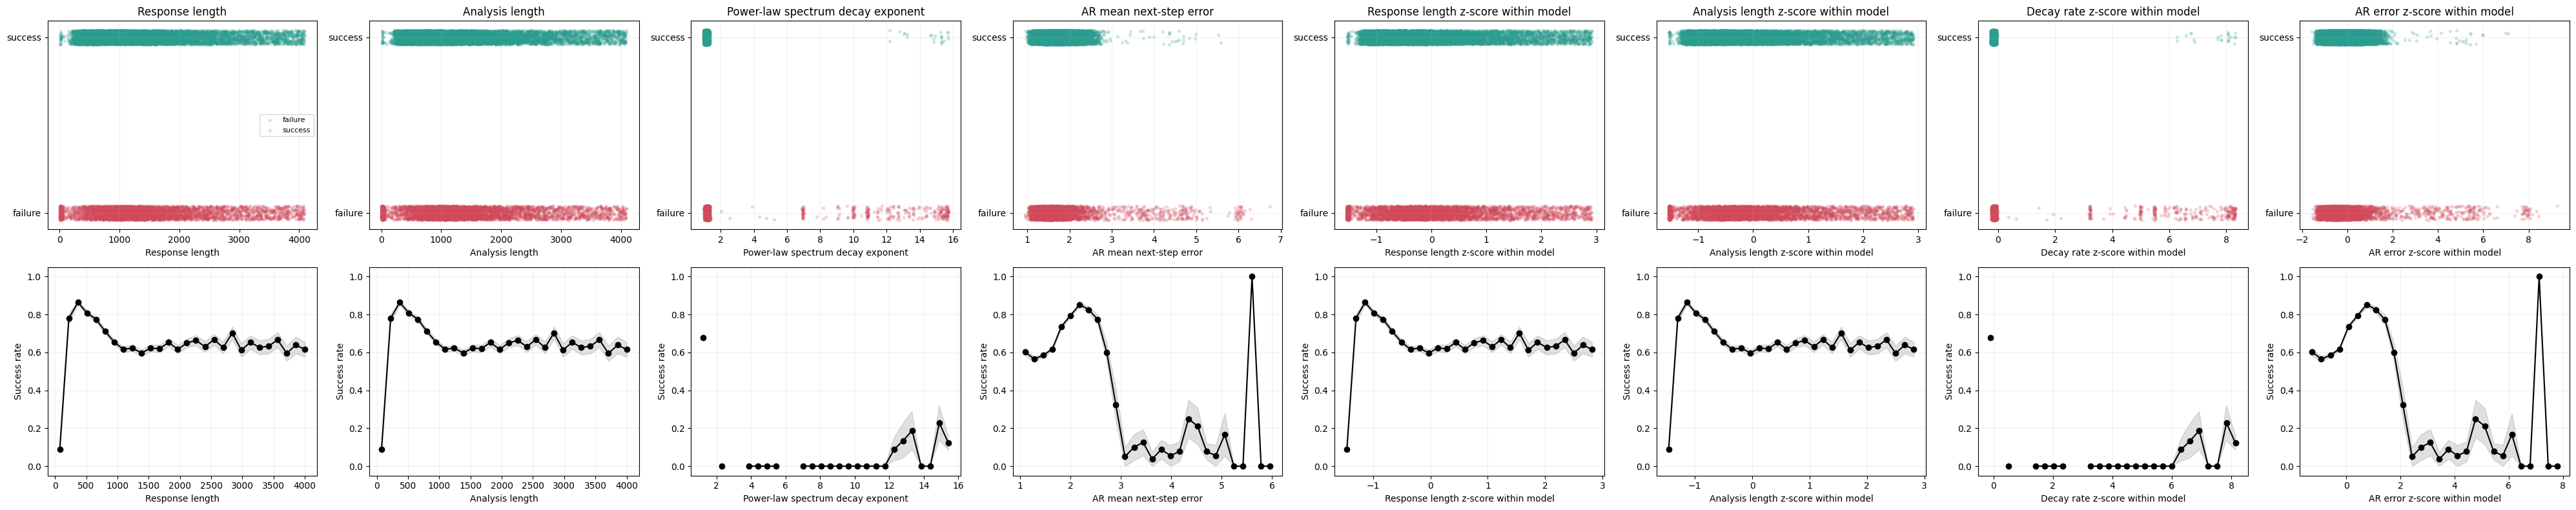

In [14]:
# Marginalized success-vs-metric scatter and binned success-rate curves.
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law spectrum decay exponent'),
    ('ar_error', 'AR mean next-step error'),
    ('response_length_z_by_model', 'Response length z-score within model'),
    ('analysis_length_z_by_model', 'Analysis length z-score within model'),
    ('decay_rate_z_by_model', 'Decay rate z-score within model'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
]

fig, axes = plt.subplots(2, len(metric_specs), figsize=(5 * len(metric_specs), 8), squeeze=False)
for col, (key, label) in enumerate(metric_specs):
    x = np.asarray([float(s[key]) for s in all_samples], dtype=np.float64)
    y = np.asarray([1.0 if s['success'] else 0.0 for s in all_samples], dtype=np.float64)
    jitter = (np.random.rand(len(y)) - 0.5) * 0.08
    fail = y == 0
    succ = y == 1
    ax = axes[0, col]
    if fail.any():
        ax.scatter(x[fail], y[fail] + jitter[fail], s=8, alpha=0.18, c='#d1495b', label='failure')
    if succ.any():
        ax.scatter(x[succ], y[succ] + jitter[succ], s=8, alpha=0.18, c='#2a9d8f', label='success')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['failure', 'success'])
    ax.grid(alpha=0.2)
    if col == 0:
        ax.legend(fontsize=8)

    ax = axes[1, col]
    lo, hi = np.percentile(x, [.1, 99.9])
    bins = np.linspace(lo, hi, 29)
    centers = 0.5 * (bins[:-1] + bins[1:])
    rates = []
    errs = []
    for b0, b1 in zip(bins[:-1], bins[1:]):
        mask = (x >= b0) & (x < b1)
        if mask.any():
            vals = y[mask]
            rates.append(float(vals.mean()))
            std = float(vals.std(ddof=1)) if vals.size > 1 else 0.0
            errs.append(std / math.sqrt(vals.size))
        else:
            rates.append(np.nan)
            errs.append(np.nan)
    ax.plot(centers, rates, marker='o', color='black')
    ax.fill_between(centers, np.asarray(rates) - np.asarray(errs), np.asarray(rates) + np.asarray(errs), color='black', alpha=0.12)
    ax.set_xlabel(label)
    ax.set_ylabel('Success rate')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


Response length
  pooled mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -118.76765636148245
  median gap: -106.39583333333326

Analysis length
  pooled mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -118.76765636148245
  median gap: -106.39583333333326

Power-law spectrum decay exponent
  pooled mixed-outcome questions: 497
  positive: 410
  negative: 87
  zero: 0
  mean gap: 0.8312105478886881
  median gap: 0.09470755481437343

AR mean next-step error
  pooled mixed-outcome questions: 497
  positive: 316
  negative: 181
  zero: 0
  mean gap: 0.15805989305091267
  median gap: 0.08506063052586144

Response length z-score within model
  pooled mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -0.12934877919476917
  median gap: -0.11587473875202278

Analysis length z-score within model
  pooled mixed-outcome questions: 497
  positive: 190
  negative: 307
  zero: 0
  mean gap: -0.129348

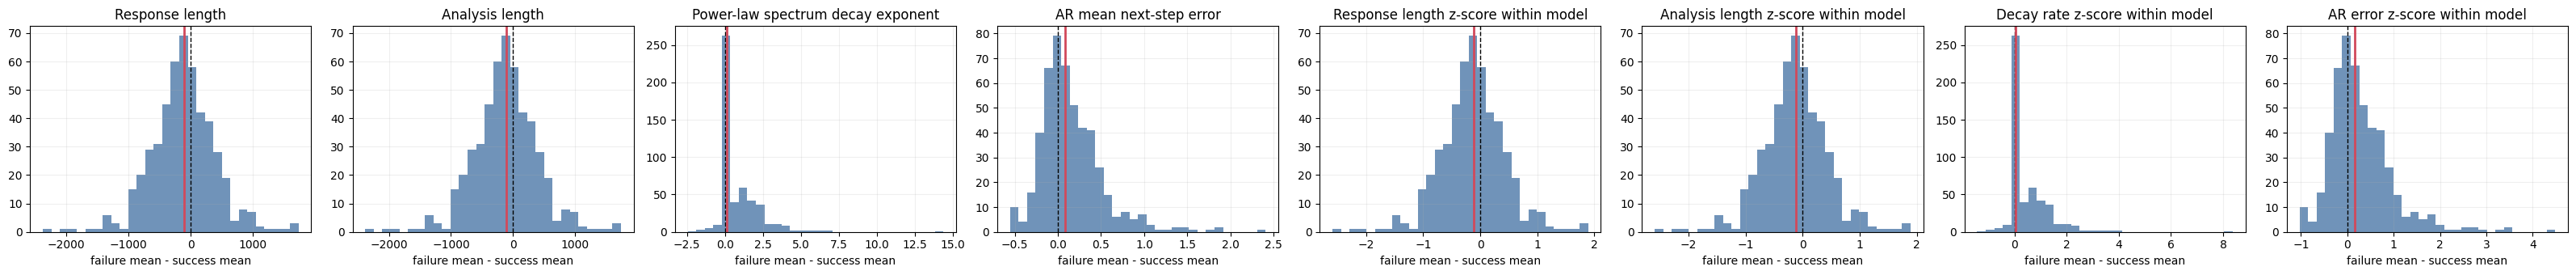

In [15]:
# Marginalized within-question paired gaps after concatenating supports across models.
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law spectrum decay exponent'),
    ('ar_error', 'AR mean next-step error'),
    ('response_length_z_by_model', 'Response length z-score within model'),
    ('analysis_length_z_by_model', 'Analysis length z-score within model'),
    ('decay_rate_z_by_model', 'Decay rate z-score within model'),
    ('ar_error_z_by_model', 'AR error z-score within model'),
]

# Concatenate supports by question_uid across all models.
by_question_all = defaultdict(list)
for s in all_samples:
    by_question_all[s['question_uid']].append(s)

for key, label in metric_specs:
    vals = []
    for qid, group in by_question_all.items():
        succ = [x for x in group if x['success']]
        fail = [x for x in group if not x['success']]
        if not succ or not fail:
            continue
        vals.append(float(np.mean([x[key] for x in fail]) - np.mean([x[key] for x in succ])))
    vals = np.asarray(vals, dtype=np.float64)
    print(label)
    print('  pooled mixed-outcome questions:', int(vals.size))
    print('  positive:', int(np.sum(vals > 0)))
    print('  negative:', int(np.sum(vals < 0)))
    print('  zero:', int(np.sum(vals == 0)))
    print('  mean gap:', float(vals.mean()) if vals.size else None)
    print('  median gap:', float(np.median(vals)) if vals.size else None)
    print()

fig, axes = plt.subplots(1, len(metric_specs), figsize=(4 * len(metric_specs), 3.5))
for ax, (key, label) in zip(axes, metric_specs):
    vals = []
    for qid, group in by_question_all.items():
        succ = [x for x in group if x['success']]
        fail = [x for x in group if not x['success']]
        if not succ or not fail:
            continue
        vals.append(float(np.mean([x[key] for x in fail]) - np.mean([x[key] for x in succ])))
    vals = np.asarray(vals, dtype=np.float64)
    if vals.size:
        ax.hist(vals, bins=30, color='#4c78a8', alpha=0.8)
        ax.axvline(0.0, color='black', linestyle='--', lw=1)
        ax.axvline(float(np.median(vals)), color='#d1495b', linestyle='-', lw=2)
    ax.set_title(label)
    ax.set_xlabel('failure mean - success mean')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [16]:
# Normalized AR error summaries by model and pooled.
print('Pooled normalized AR error summaries')
succ = np.asarray([float(s['ar_error_z_by_model']) for s in all_samples if s['success']], dtype=np.float64)
fail = np.asarray([float(s['ar_error_z_by_model']) for s in all_samples if not s['success']], dtype=np.float64)
print('  success stats:', summarize(succ))
print('  failure stats:', summarize(fail))
print('  mean(success) - mean(failure):', float(succ.mean() - fail.mean()) if succ.size and fail.size else None)
print('  median(success) - median(failure):', float(np.median(succ) - np.median(fail)) if succ.size and fail.size else None)
print()

for model_name, rows in by_model.items():
    succ = np.asarray([float(s['ar_error_z_by_model']) for s in rows if s['success']], dtype=np.float64)
    fail = np.asarray([float(s['ar_error_z_by_model']) for s in rows if not s['success']], dtype=np.float64)
    print(model_name)
    print('  success stats:', summarize(succ))
    print('  failure stats:', summarize(fail))
    print('  mean(success) - mean(failure):', float(succ.mean() - fail.mean()) if succ.size and fail.size else None)
    print('  median(success) - median(failure):', float(np.median(succ) - np.median(fail)) if succ.size and fail.size else None)
    print()


Pooled normalized AR error summaries
  success stats: {'n': 9265, 'mean': -0.018517019182899372, 'median': -0.0701731675865803, 'std': 0.7044955058469451, 'min': -1.5482346127759108, 'max': 7.092221264667152}
  failure stats: {'n': 4709, 'mean': 0.03643240236346628, 'median': -0.3271084556542186, 'std': 1.410320875998763, 'min': -1.5377352480026907, 'max': 9.265722049059935}
  mean(success) - mean(failure): -0.05494942154636565
  median(success) - median(failure): 0.25693528806763827

qwen_qwen3_4b
  success stats: {'n': 9265, 'mean': -0.018517019182899372, 'median': -0.0701731675865803, 'std': 0.7044955058469451, 'min': -1.5482346127759108, 'max': 7.092221264667152}
  failure stats: {'n': 4709, 'mean': 0.03643240236346628, 'median': -0.3271084556542186, 'std': 1.410320875998763, 'min': -1.5377352480026907, 'max': 9.265722049059935}
  mean(success) - mean(failure): -0.05494942154636565
  median(success) - median(failure): 0.25693528806763827



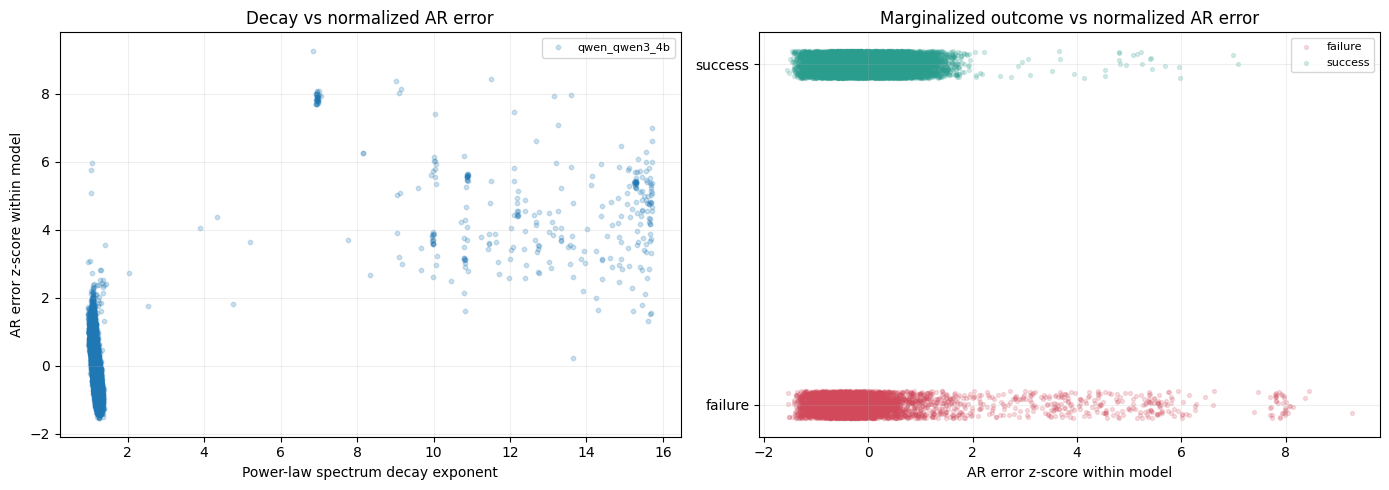

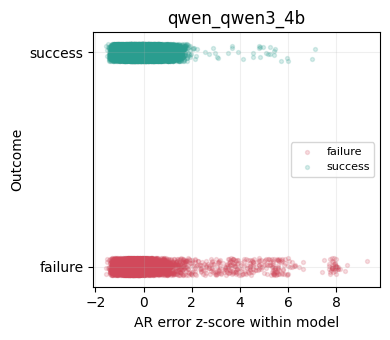

In [17]:
# Normalized AR error: pooled model-colored scatter and faceted success/failure views.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cfg in model_runs:
    rows = by_model[cfg['name']]
    x = np.asarray([float(s['decay_rate']) for s in rows], dtype=np.float64)
    y = np.asarray([float(s['ar_error_z_by_model']) for s in rows], dtype=np.float64)
    if x.size:
        axes[0].scatter(x, y, s=10, alpha=0.22, c=cfg['color'], label=cfg['name'])
axes[0].set_title('Decay vs normalized AR error')
axes[0].set_xlabel('Power-law spectrum decay exponent')
axes[0].set_ylabel('AR error z-score within model')
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)

x = np.asarray([float(s['ar_error_z_by_model']) for s in all_samples], dtype=np.float64)
y = np.asarray([1.0 if s['success'] else 0.0 for s in all_samples], dtype=np.float64)
jitter = (np.random.rand(len(y)) - 0.5) * 0.08
fail = y == 0
succ = y == 1
if fail.any():
    axes[1].scatter(x[fail], y[fail] + jitter[fail], s=8, alpha=0.18, c='#d1495b', label='failure')
if succ.any():
    axes[1].scatter(x[succ], y[succ] + jitter[succ], s=8, alpha=0.18, c='#2a9d8f', label='success')
axes[1].set_title('Marginalized outcome vs normalized AR error')
axes[1].set_xlabel('AR error z-score within model')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['failure', 'success'])
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(model_runs), figsize=(4 * len(model_runs), 3.5), squeeze=False)
for ax, cfg in zip(axes[0], model_runs):
    rows = by_model[cfg['name']]
    x = np.asarray([float(s['ar_error_z_by_model']) for s in rows], dtype=np.float64)
    y = np.asarray([1.0 if s['success'] else 0.0 for s in rows], dtype=np.float64)
    if x.size == 0:
        ax.axis('off')
        continue
    jitter = (np.random.rand(len(y)) - 0.5) * 0.08
    fail = y == 0
    succ = y == 1
    if fail.any():
        ax.scatter(x[fail], y[fail] + jitter[fail], s=8, alpha=0.18, c='#d1495b', label='failure')
    if succ.any():
        ax.scatter(x[succ], y[succ] + jitter[succ], s=8, alpha=0.18, c='#2a9d8f', label='success')
    ax.set_title(cfg['name'])
    ax.set_xlabel('AR error z-score within model')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['failure', 'success'])
    ax.grid(alpha=0.2)
axes[0][0].set_ylabel('Outcome')
axes[0][0].legend(fontsize=8)
plt.tight_layout()
plt.show()


In [18]:
# Normalized AR error within-question paired gaps, pooled and per model.
def paired_gaps(rows, key):
    by_question = defaultdict(list)
    for r in rows:
        by_question[r['question_uid']].append(r)
    vals = []
    for qid, group in by_question.items():
        succ = [x for x in group if x['success']]
        fail = [x for x in group if not x['success']]
        if not succ or not fail:
            continue
        vals.append(float(np.mean([x[key] for x in fail]) - np.mean([x[key] for x in succ])))
    return np.asarray(vals, dtype=np.float64)

print('Pooled normalized AR gap')
vals = paired_gaps(all_samples, 'ar_error_z_by_model')
print('  mixed-outcome questions:', int(vals.size))
print('  positive:', int(np.sum(vals > 0)))
print('  negative:', int(np.sum(vals < 0)))
print('  zero:', int(np.sum(vals == 0)))
print('  mean gap:', float(vals.mean()) if vals.size else None)
print('  median gap:', float(np.median(vals)) if vals.size else None)
print()

for model_name, rows in by_model.items():
    vals = paired_gaps(rows, 'ar_error_z_by_model')
    print(model_name)
    print('  mixed-outcome questions:', int(vals.size))
    print('  positive:', int(np.sum(vals > 0)))
    print('  negative:', int(np.sum(vals < 0)))
    print('  zero:', int(np.sum(vals == 0)))
    print('  mean gap:', float(vals.mean()) if vals.size else None)
    print('  median gap:', float(np.median(vals)) if vals.size else None)
    print()


Pooled normalized AR gap
  mixed-outcome questions: 497
  positive: 316
  negative: 181
  zero: 0
  mean gap: 0.294518090149857
  median gap: 0.1584962128333839

qwen_qwen3_4b
  mixed-outcome questions: 497
  positive: 316
  negative: 181
  zero: 0
  mean gap: 0.294518090149857
  median gap: 0.1584962128333839

